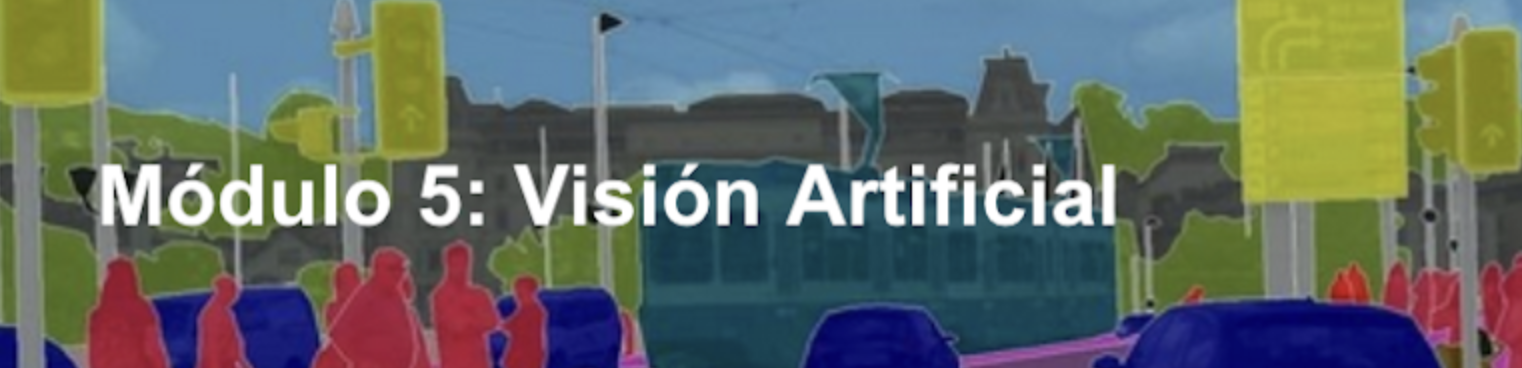

# **Ejercicio en clase, Red Neuronal Simple en PyTorch**

La siguiente figura representa el algoritmo de optimización Gradiente Descendente.

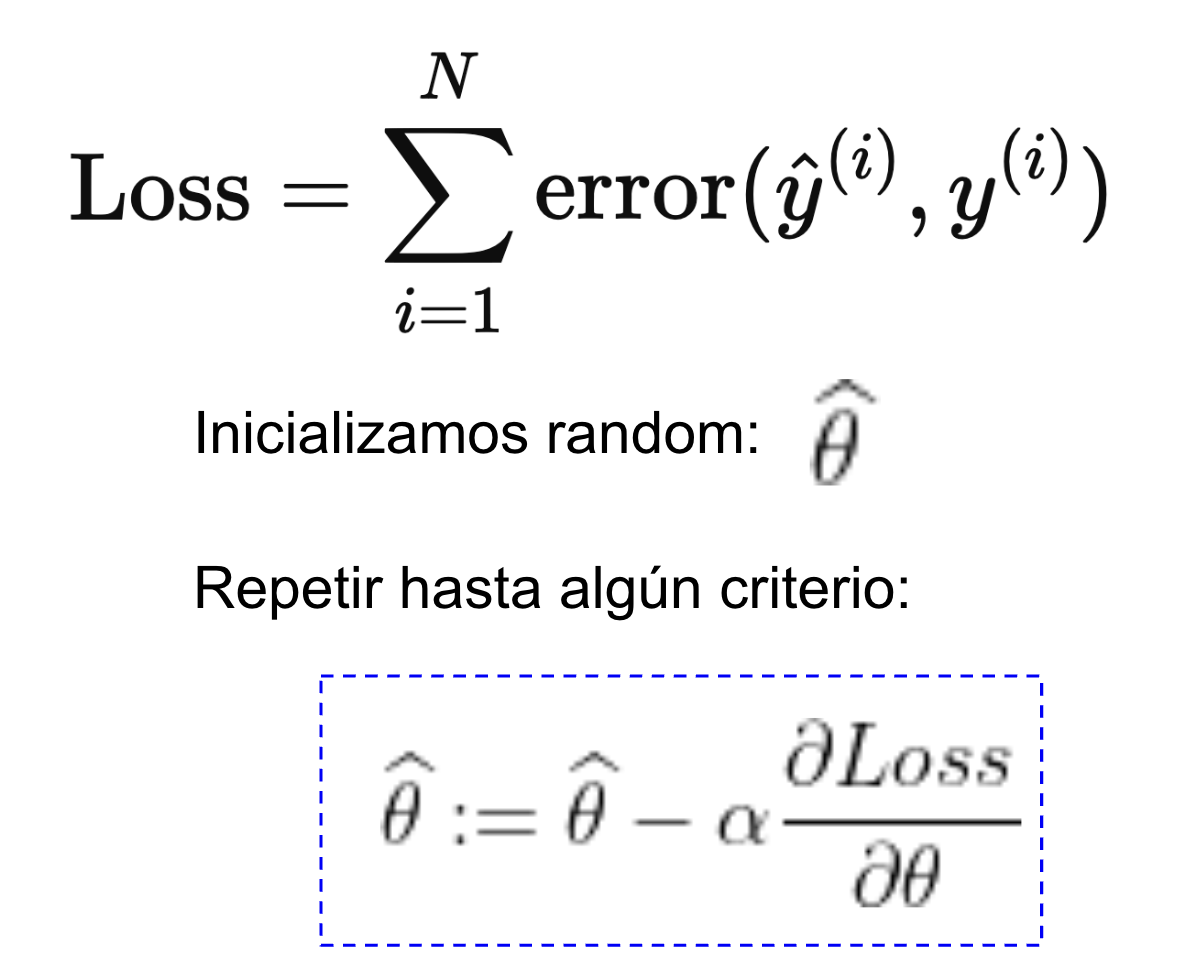

---

Importamos las librerias necesarias:

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

Creamos nuestro toy dataset:

In [ ]:
# X son las entradas, y son las etiquetas (0 o 1)
X = torch.tensor([[2.0, 3.0],
                  [5.0, 4.0],
                  [8.0, 6.0],
                  [9.0, 7.0]], requires_grad=True)

y = torch.tensor([1.0, 1.0, 0.0, 0.0]).view(-1, 1)


Armamos el modelo

Información sobre la sigmoide: https://docs.pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html

In [ ]:
model = nn.Sequential(
    nn.Linear(2, 1),
    #La salida es binaria, entonces necesitaremos la función de activación Sigmoide
    nn.Sigmoid(),
)

Definimos la función de pérdida y el optimizador

Define Binary Cross Entropy para el criterion desde https://docs.pytorch.org/docs/stable/generated/torch.nn.BCELoss.html

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)  # Utiliza 0.1 para el learning rate

Realizamos el entrenamiento del modelo

In [ ]:
epochs = 5
for epoch in range(epochs):

    print(f'\n--- Epoch {epoch + 1} ---')

    for i, (data, target) in enumerate(zip(X, y)):
        print(data, target)

        # Forward pass
        # Pasa X al modelo
        output = model(data.unsqueeze(0))

        # Calculamos la perdida con la función
        loss = criterion(output, target.unsqueeze(0))

        print(f'Batch {i + 1}:')
        print(f'  Antes del backward: Pesos {model[0].weight.data.numpy()}')

        # Realizamos la Backward pass
        loss.backward()
        print(f'  Gradientes calculadas: {model[0].weight.grad.numpy()}')

        # Actualizamos los pesos
        optimizer.step()
        print(f'  Después del step: Pesos actualizados {model[0].weight.data.numpy()}')

        # Ponemos a cero los gradientes
        optimizer.zero_grad()


Realizamos una predicción final despues de realizar el entrenamiento

In [ ]:
with torch.no_grad():
    predicted = model(X)
    print("\nPredicciones después del entrenamiento:")
    print(predicted)

Verificamos la actualización de pesos:


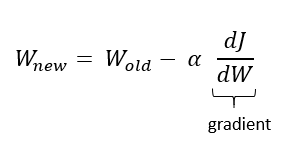

In [ ]:
'''
Comprueba que se cumple la formula. Extrae un bloque y compruebalo.

Por ejemplo:
Antes del backward: Pesos [[-0.38771573  0.71995   ]]
Gradientes calculadas: [[6.832888 5.124666]]
Después del step: Pesos actualizados [[-1.0710045  0.2074834]])

w_nuevo = -0.38771573 - (0.1 * 6.832888)
print(w_nuevo)
'''

In [ ]:
# Comprobación manual: w_nuevo = w_antes - lr * grad (mismo bloque que en el ejemplo de arriba)
w_antes = torch.tensor([-0.38771573, 0.71995])
grad = torch.tensor([6.832888, 5.124666])
lr = 0.1
w_nuevo = w_antes - lr * grad
print("w_nuevo por fórmula:", w_nuevo.numpy())
print("Coincide con 'Pesos actualizados' del ejemplo: [[-1.0710045  0.2074834]]")